# Unsupervised Learning: DBSCAN Clustering

---

## Introduction

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) groups points that are closely packed and marks low-density points as **outliers/noise**. Unlike K-Means, it does not require specifying `k` and can find clusters of arbitrary shape.

### Key Concepts

| Term | Definition |
|---|---|
| `eps` | Neighbourhood radius — max distance to be considered a neighbour |
| `min_samples` | Minimum points within `eps` to form a core point |
| **Core point** | Has at least `min_samples` neighbours within `eps` |
| **Border point** | Within `eps` of a core point but has fewer neighbours |
| **Noise point** | Neither core nor border — assigned label **-1** |

### DBSCAN vs. K-Means

| Property | K-Means | DBSCAN |
|---|---|---|
| Requires `k` | Yes | No |
| Cluster shape | Spherical only | Arbitrary |
| Handles outliers | No | Yes (label = -1) |
| Scales to large data | Fast | Slower |

This notebook demonstrates DBSCAN on a small manual dataset and on concentric circles — a shape K-Means cannot handle.

---
## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import make_circles, make_blobs
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

SyntaxError: source code string cannot contain null bytes (<string>)

---
## 2. Small Manual Dataset — Understanding Core/Border/Noise Points

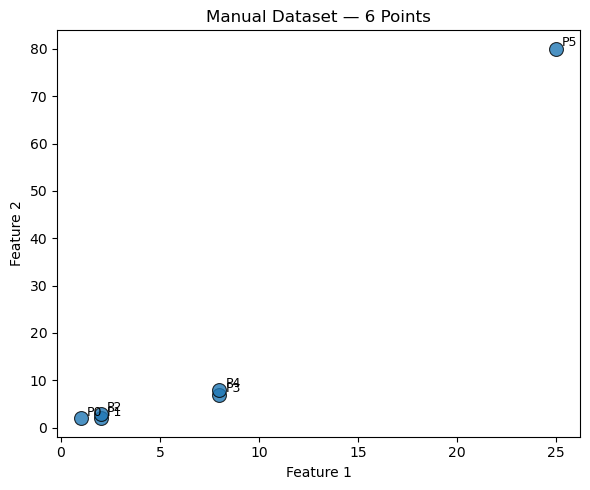

Labels: [ 0  0  0  0  0 -1]
(Label -1 = noise/outlier)
  P0 [1 2] -> Cluster 0
  P1 [2 2] -> Cluster 0
  P2 [2 3] -> Cluster 0
  P3 [8 7] -> Cluster 0
  P4 [8 8] -> Cluster 0
  P5 [25 80] -> NOISE


In [2]:
X_small = np.array([[1, 2], [2, 2], [2, 3], [8, 7], [8, 8], [25, 80]])

plt.figure(figsize=(6, 5))
plt.scatter(X_small[:, 0], X_small[:, 1], s=100,
            edgecolors='k', linewidths=0.8, alpha=0.8)
for i, (x, y) in enumerate(X_small):
    plt.annotate(f'P{i}', (x + 0.3, y + 0.5), fontsize=9)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Manual Dataset — 6 Points')
plt.tight_layout()
plt.show()

# Apply DBSCAN
db = DBSCAN(eps=9, min_samples=2)
db.fit(X_small)

print('Labels:', db.labels_)
print('(Label -1 = noise/outlier)')
for i, label in enumerate(db.labels_):
    tag = 'NOISE' if label == -1 else f'Cluster {label}'
    print(f'  P{i} {X_small[i]} -> {tag}')

---
## 3. DBSCAN on Concentric Circles — Where K-Means Fails

K-Means cannot separate concentric rings because it assumes spherical clusters. DBSCAN uses density and correctly identifies both rings.

DBSCAN — Clusters found: 4  |  Noise points: 0


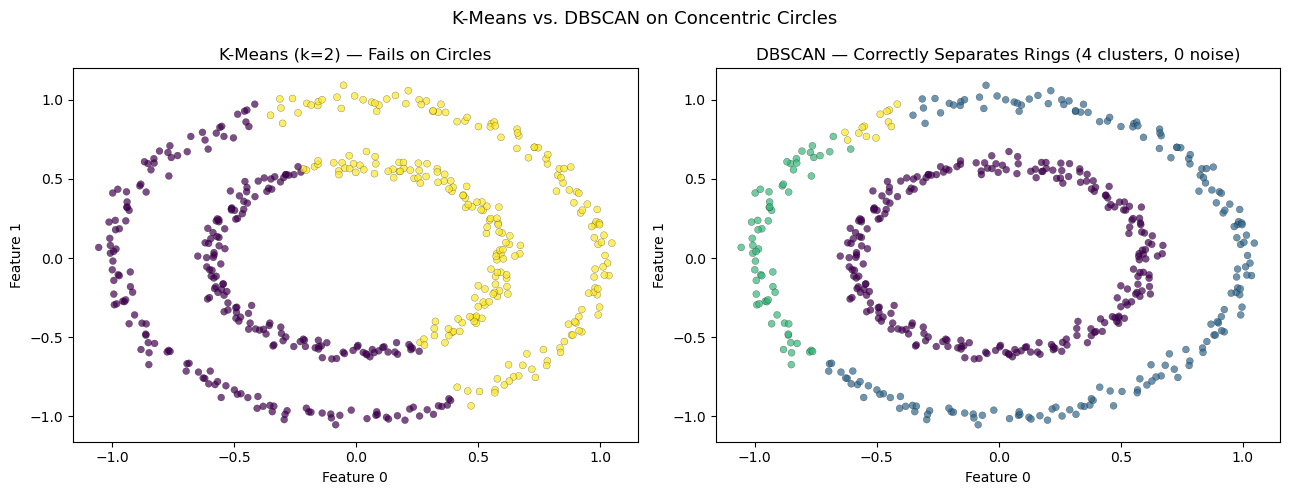

In [3]:
X_circles, _ = make_circles(n_samples=500, factor=0.6, noise=0.03, random_state=42)

# Fit both models
dbscan  = DBSCAN(eps=0.1, min_samples=5)
kmeans  = KMeans(n_clusters=2, random_state=42, n_init=10)

labels_db = dbscan.fit_predict(X_circles)
labels_km = kmeans.fit_predict(X_circles)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise       = (labels_db == -1).sum()

print(f'DBSCAN — Clusters found: {n_clusters_db}  |  Noise points: {n_noise}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(X_circles[:, 0], X_circles[:, 1], c=labels_km,
                cmap='viridis', alpha=0.7, edgecolors='k', linewidths=0.2, s=25)
axes[0].set_title('K-Means (k=2) — Fails on Circles')
axes[0].set_xlabel('Feature 0')
axes[0].set_ylabel('Feature 1')

axes[1].scatter(X_circles[:, 0], X_circles[:, 1], c=labels_db,
                cmap='viridis', alpha=0.7, edgecolors='k', linewidths=0.2, s=25)
axes[1].set_title(f'DBSCAN — Correctly Separates Rings ({n_clusters_db} clusters, {n_noise} noise)')
axes[1].set_xlabel('Feature 0')
axes[1].set_ylabel('Feature 1')

plt.suptitle('K-Means vs. DBSCAN on Concentric Circles', fontsize=13)
plt.tight_layout()
plt.show()

---
## 4. Effect of eps and min_samples

DBSCAN's behaviour is highly sensitive to `eps` and `min_samples`. We visualize how different `eps` values affect cluster discovery.

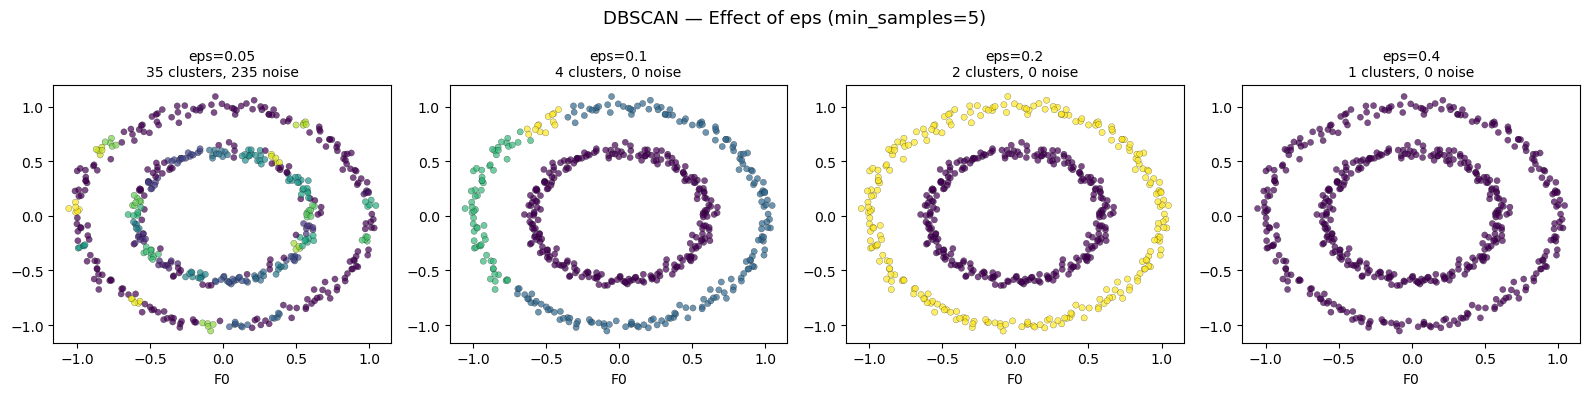

In [4]:
eps_values = [0.05, 0.1, 0.2, 0.4]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, eps in zip(axes, eps_values):
    labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X_circles)
    n_clust = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    ax.scatter(X_circles[:, 0], X_circles[:, 1], c=labels,
               cmap='viridis', alpha=0.7, edgecolors='k', linewidths=0.2, s=20)
    ax.set_title(f'eps={eps}\n{n_clust} clusters, {n_noise} noise', fontsize=10)
    ax.set_xlabel('F0')

plt.suptitle('DBSCAN — Effect of eps (min_samples=5)', fontsize=13)
plt.tight_layout()
plt.show()

---
## Conclusion

- DBSCAN correctly identified **two concentric rings** — a task impossible for K-Means, which always produces convex cluster boundaries.
- The **noise label (-1)** is a built-in outlier detection mechanism — points that don't belong to any dense region are automatically flagged.
- The **eps sensitivity plot** shows that too-small `eps` fragments clusters while too-large `eps` merges them. Choosing `eps` well requires domain knowledge or using a k-distance graph.
- Best practice for `eps` selection: sort each point's distance to its k-th nearest neighbour and look for the "elbow" in that curve.